# Importing Dependencies

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Data Collection and Preprocessing

In [88]:
customer_data = pd.read_csv('Mall_Customers.csv')

In [89]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [90]:
customer_data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [91]:
# No of rows and cols

customer_data.shape

(200, 5)

In [92]:
# Getting information about dataset

customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [93]:
customer_data['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

In [94]:
# Checking Missing values

customer_data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [95]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [96]:
customer_data= customer_data.replace({'Gender':{'Male':0, 'Female':1}})

C:\Users\abbas\AppData\Local\Temp\ipykernel_11072\2382037016.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  customer_data= customer_data.replace({'Gender':{'Male':0, 'Female':1}})


In [97]:
customer_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


# Choosing Required Columns

In [98]:
# Gender, Age, Annual Income, Spending score columns

X = customer_data.drop(columns='CustomerID', axis=1).values

In [99]:
print(X)

[[  0  19  15  39]
 [  0  21  15  81]
 [  1  20  16   6]
 [  1  23  16  77]
 [  1  31  17  40]
 [  1  22  17  76]
 [  1  35  18   6]
 [  1  23  18  94]
 [  0  64  19   3]
 [  1  30  19  72]
 [  0  67  19  14]
 [  1  35  19  99]
 [  1  58  20  15]
 [  1  24  20  77]
 [  0  37  20  13]
 [  0  22  20  79]
 [  1  35  21  35]
 [  0  20  21  66]
 [  0  52  23  29]
 [  1  35  23  98]
 [  0  35  24  35]
 [  0  25  24  73]
 [  1  46  25   5]
 [  0  31  25  73]
 [  1  54  28  14]
 [  0  29  28  82]
 [  1  45  28  32]
 [  0  35  28  61]
 [  1  40  29  31]
 [  1  23  29  87]
 [  0  60  30   4]
 [  1  21  30  73]
 [  0  53  33   4]
 [  0  18  33  92]
 [  1  49  33  14]
 [  1  21  33  81]
 [  1  42  34  17]
 [  1  30  34  73]
 [  1  36  37  26]
 [  1  20  37  75]
 [  1  65  38  35]
 [  0  24  38  92]
 [  0  48  39  36]
 [  1  31  39  61]
 [  1  49  39  28]
 [  1  24  39  65]
 [  1  50  40  55]
 [  1  27  40  47]
 [  1  29  40  42]
 [  1  31  40  42]
 [  1  49  42  52]
 [  0  33  42  60]
 [  1  31  4

# Choosing the number of clustures

- This help us to find the best (optimal) no of clustures suitable for our dataset

WCSS - Within Clustures Sum of Squares 

In [100]:
# Finding WCSS value for different number of clustures

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42) # Best initiation method is k-means++
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

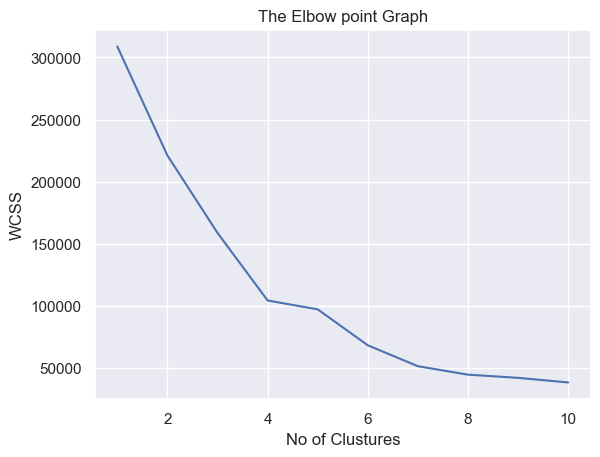

In [101]:
# Plot an Elbow graph to find which clusture have minimum value

sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow point Graph')
plt.xlabel('No of Clustures')
plt.ylabel('WCSS')
plt.show()

we can see a suddent change thats is elbow points here we take 5

Optimal no of clustures will be 5

# Training K means Clusturing Model 

In [102]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# Return a lable for each data point based on thier clusture   -  All our dataset will be converted into clustures based on thier values and each value with get an label


Y = kmeans.fit_predict(X)

In [103]:
print(Y)

[2 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0 2 0
 2 0 2 0 2 0 2 0 2 0 4 4 4 0 4 4 0 0 0 0 0 4 0 0 4 0 0 0 4 4 0 4 4 0 0 0 0
 0 4 4 4 4 0 0 4 0 4 4 4 4 4 4 4 0 4 4 4 4 4 4 4 4 4 4 4 0 4 4 4 0 4 0 0 0
 4 4 4 4 4 0 4 4 4 4 4 4 1 4 1 4 1 3 1 3 1 4 1 3 1 3 1 3 1 3 1 4 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


# Visualization All The Clustures

5 Clustures - 0, 1, 2, 3, 4

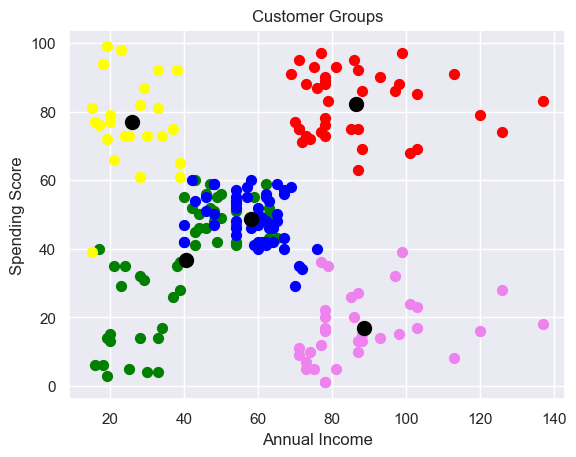

In [104]:
# Plotting all the clustures and thier centroids

plt.Figure(figsize=(6,6))
plt.scatter(X[Y== 0,2], X[Y==0,3], s=50, c='green', label = 'Clusture 1')  
plt.scatter(X[Y== 1,2], X[Y==1,3], s=50, c='red', label = 'Clusture 2')
plt.scatter(X[Y== 2,2], X[Y==2,3], s=50, c='yellow', label = 'Clusture 3')
plt.scatter(X[Y== 3,2], X[Y==3,3], s=50, c='violet', label = 'Clusture 4')
plt.scatter(X[Y== 4,2], X[Y==4,3], s=50, c='blue', label = 'Clusture 5')

# Plot the Centroid

plt.scatter(kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:, 3], s = 100, c='black', label='centroid')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()